<a href="https://colab.research.google.com/github/NiliS2006/SCT_ML/blob/main/SCT_ML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
gti_upm_leapgestrecog_path = kagglehub.dataset_download('gti-upm/leapgestrecog')

print('Data source import complete.')


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0067.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0153.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0105.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0018.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0050.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0029.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0195.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0051.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/frame_07_02_0074.png
/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07/02_l/f

In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
dataset_path = (
    "/kaggle/input/datasets/organizations/"
    "gti-upm/leapgestrecog/leapGestRecog"
)

In [ ]:
datagen = ImageDataGenerator(rescale=1/255, validation_split=0.2)

In [ ]:
train_data = datagen.flow_from_directory(dataset_path, target_size=(64,64), batch_size=32, class_mode='categorical',subset='validation')

Found 4000 images belonging to 10 classes.


In [ ]:
validation_data = datagen.flow_from_directory(dataset_path, target_size=(64, 64), batch_size=32, class_mode='categorical', subset='validation')

Found 4000 images belonging to 10 classes.


In [ ]:
model = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)), MaxPooling2D(pool_size=(2,2)), Conv2D(64, (3,3), activation='relu'), MaxPooling2D(pool_size=(2,2)), Flatten(), Dense(128, activation='relu'), Dropout(0.5), Dense(10, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-13 16:51:09.710423: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(train_data, validation_data=validation_data, epochs=10)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 330ms/step - accuracy: 0.7410 - loss: 0.7713 - val_accuracy: 0.9912 - val_loss: 0.0439
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.9740 - loss: 0.0927 - val_accuracy: 0.9998 - val_loss: 0.0022
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 254ms/step - accuracy: 0.9815 - loss: 0.0557 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 1.0000 - val_loss: 6.8433e-05
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 252ms/step - accuracy: 0.9902 - loss: 0.0320 - val_accuracy: 1.0000 - val_loss: 5.5971e-04
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.9923 - loss: 0.0207 - val_accuracy: 1.0000 - val_loss: 3.6667e-04
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 255ms/step - accuracy: 0.9930 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss: 5.5351e-05
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 256ms/step - accuracy: 

In [ ]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 1.0000 - loss: 2.7548e-05
Validation Accuracy: 1.0


In [ ]:
model.save("hand_gesture_model.keras")

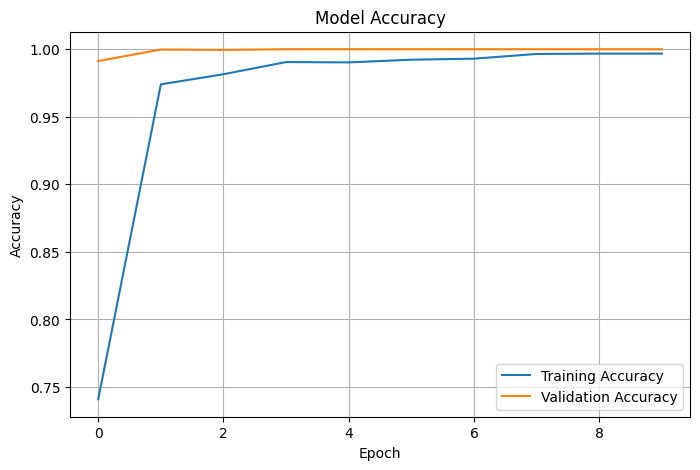

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

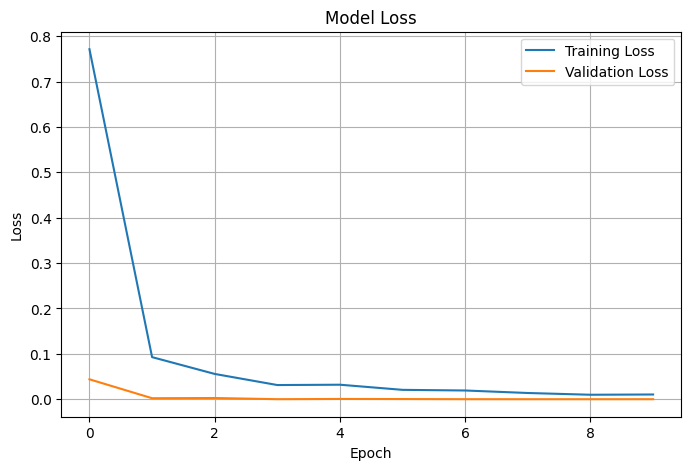

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,879,328 (18.61 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,252,886 (12.41 MB)

In [ ]:
import cv2

def predict_gesture(image_path):

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        print("Image could not be loaded")
        return

    # Convert BGR to RGB
    display_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Resize image
    processed_image = cv2.resize(
        image,
        (64, 64)
    )

    # Normalize
    processed_image = (
        processed_image.astype("float32") / 255.0
    )

    # Add batch dimension
    processed_image = np.expand_dims(
        processed_image,
        axis=0
    )

    # Predict
    prediction = model.predict(
        processed_image
    )

    predicted_class = np.argmax(
        prediction
    )

    confidence = np.max(
        prediction
    ) * 100

    gesture = encoder.inverse_transform(
        [predicted_class]
    )[0]

    # Display image
    plt.figure(figsize=(6, 6))

    plt.imshow(display_image)

    plt.title(
        f"Predicted Gesture: {gesture}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()

    print("Gesture:", gesture)
    print("Confidence:", confidence)

In [ ]:
predict_gesture(
    "/kaggle/input/your-image-folder/hand.jpg"
)

Image could not be loaded


[ WARN:0@861.357] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/your-image-folder/hand.jpg'): can't open/read file: check file path/integrity


In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

random_indices = np.random.choice(
    len(X_test),
    12,
    replace=False
)

plt.figure(figsize=(15, 10))

for i, index in enumerate(random_indices):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    actual = encoder.inverse_transform(
        [y_test[index]]
    )[0]

    predicted = encoder.inverse_transform(
        [predicted_labels[index]]
    )[0]

    confidence = (
        np.max(predictions[index]) * 100
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'X_test' is not defined